In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

# Load MNIST data
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target

# Split into training and test sets (MNIST is already shuffled)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


In [2]:
# Convert labels to integers
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)

# Create binary target: True for all 3s, False for all other digits
y_train_3 = (y_train == 3)
y_test_3 = (y_test == 3)


In [5]:
from sklearn.linear_model import SGDClassifier

# Initialize the classifier with a random_state for reproducibility
sgd_clf = SGDClassifier(random_state=42)

# Train the model
sgd_clf.fit(X_train, y_train_3)


SGDClassifier(random_state=42)

In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Get cross-validated predictions
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)

# Generate confusion matrix
cm = confusion_matrix(y_train_3, y_train_pred)
print(cm)


[[53477   392]
 [ 2113  4018]]


In [9]:
from sklearn.linear_model import SGDClassifier

# Initialize the classifier
sgd_clf = SGDClassifier(random_state=42)

# Train on the first 60,000 images
sgd_clf.fit(X_train, y_train_3)


SGDClassifier(random_state=42)

In [10]:
# Predict on the held-out test set
y_test_pred = sgd_clf.predict(X_test)


In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Calculate test accuracy
test_accuracy = accuracy_score(y_test_3, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Display the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test_3, y_test_pred))


Test Accuracy: 0.9535
Confusion Matrix:
[[8978   12]
 [ 453  557]]


In [15]:
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. Get cross-validated accuracy
accuracy_scores = cross_val_score(sgd_clf, X_train, y_train_3, cv=3, scoring="accuracy")
print(f"Accuracy: {accuracy_scores.mean():.4f}")

# 2. Get cross-validated predictions for other metrics
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)


Accuracy: 0.9582


In [16]:
# Confusion Matrix
cm = confusion_matrix(y_train_3, y_train_pred)
print("Confusion Matrix:\n", cm)

# Precision, Recall, and F1 Score
print(f"Precision: {precision_score(y_train_3, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train_3, y_train_pred):.4f}")
print(f"F1 Score: {f1_score(y_train_3, y_train_pred):.4f}")


Confusion Matrix:
 [[53477   392]
 [ 2113  4018]]
Precision: 0.9111
Recall: 0.6554
F1 Score: 0.7624


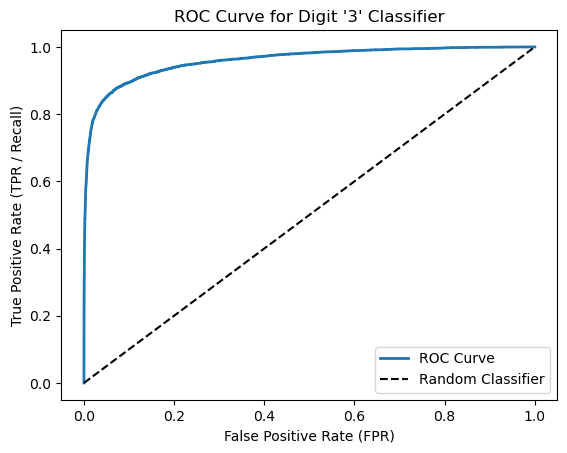

ROC AUC Score: 0.9599


In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Get decision scores instead of labels
y_scores = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3, method="decision_function")

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_train_3, y_scores)

# Plotting
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR / Recall)")
plt.title("ROC Curve for Digit '3' Classifier")
plt.legend()
plt.show()

# Calculate Area Under Curve (AUC)
print(f"ROC AUC Score: {roc_auc_score(y_train_3, y_scores):.4f}")


In [20]:
# 1. Get the raw decision scores
y_scores = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3, method="decision_function")

# 2. Define a custom threshold (e.g., to increase precision, use a higher positive value)
custom_threshold = 5000 
y_train_pred_custom = (y_scores > custom_threshold)


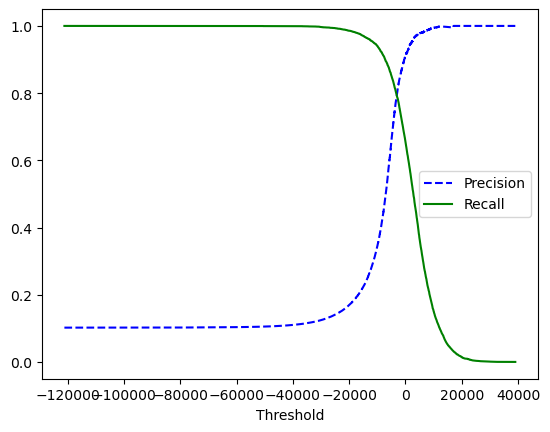

In [22]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_3, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()


In [25]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize and train on all 10 classes
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train) # Use original y_train (0-9)

# Generate cross-validated predictions for all 10 digits
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)


<Figure size 1000x1000 with 0 Axes>

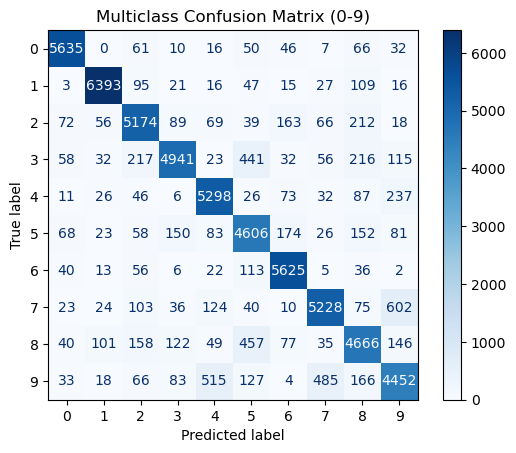

In [26]:
# Create the confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)

# Visualize using a heatmap
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mx, display_labels=range(10))
disp.plot(cmap="Blues", values_format='d')
plt.title("Multiclass Confusion Matrix (0-9)")
plt.show()


In [28]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Generate cross-validated predictions for all 10 digits (0-9)
# Note: Ensure you are using the original y_train (integers 0-9), not the binary y_train_3
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3)

# 2. Create the raw confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)

# 3. Wrap it in a Pandas DataFrame for better readability (optional)
conf_mx_df = pd.DataFrame(conf_mx, 
                          index=[f"Actual {i}" for i in range(10)], 
                          columns=[f"Pred {i}" for i in range(10)])

print(conf_mx_df)


          Pred 0  Pred 1  Pred 2  Pred 3  Pred 4  Pred 5  Pred 6  Pred 7  \
Actual 0    5635       0      61      10      16      50      46       7   
Actual 1       3    6393      95      21      16      47      15      27   
Actual 2      72      56    5174      89      69      39     163      66   
Actual 3      58      32     217    4941      23     441      32      56   
Actual 4      11      26      46       6    5298      26      73      32   
Actual 5      68      23      58     150      83    4606     174      26   
Actual 6      40      13      56       6      22     113    5625       5   
Actual 7      23      24     103      36     124      40      10    5228   
Actual 8      40     101     158     122      49     457      77      35   
Actual 9      33      18      66      83     515     127       4     485   

          Pred 8  Pred 9  
Actual 0      66      32  
Actual 1     109      16  
Actual 2     212      18  
Actual 3     216     115  
Actual 4      87     237  
A